In [ ]:
# | default_exp dmd_scaling_dataset

# Hyperparam Tuning for the Yin-Yang MLP

> We scale a neural network by freezing it and adding new trainable layers.

#### Imports and Setup

In [ ]:
import os
from ast import literal_eval
from copy import deepcopy

import graphviz
import matrepr
import torch
import torchinfo
from safetensors.torch import load_model, save_model
from torch import nn
from torch.nn import CrossEntropyLoss, L1Loss, MSELoss, HuberLoss
from torch.optim import SGD, Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchviz import make_dot

from learningdynamics.datasets import YinYangBinaryDataset
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
import numpy as np
from learningdynamics.visualization import plot_decision_boundary_movie
import matplotlib.pyplot as plt
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from functools import partial

In [ ]:
# | hide
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"
graphviz.set_jupyter_format("png")

%matplotlib inline

#### Load model

In [ ]:
file_path = "/workspaces/learningdynamics/saved_weights/yinyang_model.safetensors"

# Parse metadata
metadata = safetensors_metadata_parser(file_path=file_path)
PROBLEM = metadata["dataset"]

# Load model
model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(model, file_path, device="cuda:0")

#### Setup the dataset

In [ ]:
NUM_SAMPLES = 2_000

dataset = YinYangBinaryDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=123)

#### Visualize decision boundary

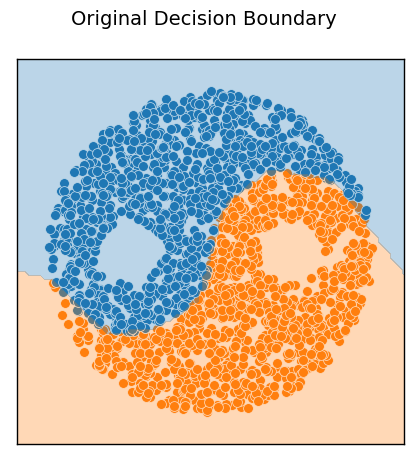

In [ ]:
# Example of integrating multiple subplots into a larger figure
fig, axs = plt.subplots(1,1, figsize=(5,5), sharex=True, sharey=True)

if type(axs) is not np.ndarray:
    axs = np.array(axs)

# Assume you have a model, state_dicts, X, and y already defined
for i, ax in enumerate(axs.flatten()):
    ani = plot_decision_boundary_movie(
            model,
            [model.state_dict()],
            dataset.features,
            dataset.labels.squeeze(),
            labels=[0, 1],
            ax=ax,
    )
    ax.get_legend().remove()

plt.suptitle("Original Decision Boundary", fontsize=14)
# fig.supxlabel('common x label', fontsize=12)
# fig.supylabel('common y label', fontsize=12)
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
print(f"Testing Accuracy: {compute_model_accuracy(model, dataset)}")

Testing Accuracy: 0.984499990940094


In [ ]:
torchinfo.summary(model, row_settings=["var_names", "ascii_only"])

Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (features)                  --
|    + Linear (0)                        24
|    + ReLU (1)                          --
|    + Linear (2)                        54
|    + ReLU (3)                          --
|    + Linear (4)                        28
|    + ReLU (5)                          --
|    + Linear (6)                        15
|    + ReLU (7)                          --
|    + Linear (8)                        8
Total params: 129
Trainable params: 129
Non-trainable params: 0

#### Define model scaling

In [ ]:
def freeze_and_scale_model(
    model,
    start,
    layers_to_add=1,
    device="cuda:0",
):
    # Set up scaled model
    model.to(device)
    scaled_model = deepcopy(model)

    # Build new layers
    scaled_container = torch.nn.Sequential()
    for idx, module in enumerate(scaled_model.features):
        if hasattr(module, "weight"):
            module.weight.requires_grad_(False)
        if hasattr(module, "bias"):
            module.bias.requires_grad_(False)
        scaled_container.append(module)
        if idx == start:
            prev_out = model.features[idx - 1].out_features
            for _ in range(layers_to_add):
                linear_layer = nn.Linear(prev_out, prev_out)
                linear_layer.apply(init_weights)
                scaled_container.append(linear_layer)
                scaled_container.append(nn.ReLU())
    scaled_model.features = scaled_container
    scaled_model.to(device=device)

    scaled_model.to(device="cpu")
    return scaled_model

#### Control panel

In [ ]:
DEVICE = "cuda:0"
PRINT_FREQ = 500

NUM_LAYERS_ADDED = 10
LAYER_START = 3
DIMENSIONALITY = model.features[LAYER_START + 1].in_features
LAYER_END = LAYER_START + 2

NUM_EPOCHS = 5_000
BATCHSIZE = 512


#### Scale model

In [ ]:
scaled_model = freeze_and_scale_model(
    model,
    start=LAYER_START,
    layers_to_add=NUM_LAYERS_ADDED,
)

torchinfo.summary(scaled_model, row_settings=["var_names", "ascii_only"])

Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (features)                  --
|    + Linear (0)                        (24)
|    + ReLU (1)                          --
|    + Linear (2)                        (54)
|    + ReLU (3)                          --
|    + Linear (4)                        42
|    + ReLU (5)                          --
|    + Linear (6)                        42
|    + ReLU (7)                          --
|    + Linear (8)                        42
|    + ReLU (9)                          --
|    + Linear (10)                       42
|    + ReLU (11)                         --
|    + Linear (12)                       42
|    + ReLU (13)                         --
|    + Linear (14)                       42
|    + ReLU (15)                         --
|    + Linear (16)                       42
|    + ReLU (17)                         --
|    + Linear (18)                       42
|    + ReLU (19)       

In [ ]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

Testing Accuracy: 0.5005000233650208


#### Train scaled model

In [ ]:
# Define the training function
def train_model(config):

    model = MLP(
        config=literal_eval(metadata["config"]), 
        nonlinearity=metadata["nonlinearity"]
    )
    
    _ = load_model(model, file_path, device=DEVICE)

    scaled_model = freeze_and_scale_model(
        model,
        start=LAYER_START,
        layers_to_add=NUM_LAYERS_ADDED,
    )
    
    scaled_model.to(DEVICE)
    scaled_model.train()
    
    dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=config["batchsize"])
    
    activation_dict = {}

    # Setup training
    huber_criterion = HuberLoss(delta=1)
    optimizer = AdamW(
        scaled_model.parameters(),
        lr=config["lr"],
        betas=(config["beta1"], config["beta2"]),
        weight_decay=5e-3,
    )

    hooks = []
    hooks.append(
        model.features[LAYER_END].register_forward_hook(
            getActivation(f"layer_{LAYER_END}", activation_dict)
        )
    )
    new_end = LAYER_END + NUM_LAYERS_ADDED * 2
    hooks.append(
        scaled_model.features[new_end].register_forward_hook(
            getActivation(f"scaled_layer_{new_end}", activation_dict, detach=False)
        )
    )

    loss_vector = []
    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0

        for input, label in dataloader:
            input, label = input.to(DEVICE), torch.flatten(label.to(DEVICE))
            output = scaled_model(input)

            with torch.no_grad():
                _ = model(input)

            optimizer.zero_grad()
            output_activation = activation_dict[f"scaled_layer_{new_end}"].to(DEVICE)
            target_activation = activation_dict[f"layer_{LAYER_END}"].to(DEVICE)
            huber_loss = huber_criterion(output_activation, target_activation)

            loss = huber_loss
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(dataloader)
        loss_vector.append(epoch_loss)

        ray.train.report(dict(loss=epoch_loss))

    for hook in hooks:
        hook.remove()

In [ ]:

# Define the search space
search_space = {
    "lr": tune.qloguniform(1e-3, 5e-3, 1e-3),
    "beta1": tune.qloguniform(0.2, 0.9, 1e-1),
    "beta2": tune.qloguniform(0.5, 0.99, 1e-2),
    "batchsize": 512,
    "weight_decay": 1e-3,
}

# Configure the scheduler
asha_scheduler = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=1_000,
    grace_period=500,
    reduction_factor=4
)

# Run the hyperparameter tuning
analysis = tune.run(
    partial(train_model),
    config=search_space,
    num_samples=50,  # Number of different hyperparameter combinations to try
    scheduler=asha_scheduler,
    resources_per_trial={"cpu": 4, "gpu": 0.05}  # Adjust based on your resources
)
print("Best hyperparameters found were: ", analysis.get_best_config("loss", mode="min"))


2024-08-10 07:27:39,896	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


Trial name,loss
train_model_06413_00000,0.0374799
train_model_06413_00001,0.000444586
train_model_06413_00002,0.0784751
train_model_06413_00003,0.0782491
train_model_06413_00004,0.0408443
train_model_06413_00005,0.0781453
train_model_06413_00006,0.0783607
train_model_06413_00007,0.0379597
train_model_06413_00008,0.0376225
train_model_06413_00009,0.0377996


2024-08-10 07:29:39,277	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_model_2024-08-10_07-27-39' in 0.0391s.
2024-08-10 07:29:39,292	INFO tune.py:1041 -- Total run time: 119.40 seconds (119.33 seconds for the tuning loop).


Best hyperparameters found were:  {'lr': 0.004, 'beta1': 0.6000000000000001, 'beta2': 0.9, 'batchsize': 512, 'weight_decay': 0.001}


In [ ]:
df = analysis.results_df
sorted_df = df.sort_values(by="loss", ascending=True)
display(sorted_df.head(20))

,loss,timestamp,checkpoint_dir_name,done,training_iteration,date,time_this_iter_s,time_total_s,pid,hostname,node_ip,time_since_restore,iterations_since_restore,experiment_tag,config/lr,config/beta1,config/beta2,config/batchsize,config/weight_decay
trial_id,,,,,,,,,,,,,,,,,,,
06413_00011,0.000079,1723274895,None,True,1000,2024-08-10_07-28-15,0.020026,29.586642,562215,e1bb1df5c343,172.17.0.3,29.586642,1000,"11_beta1=0.6000,beta2=0.9000,lr=0.0040",0.004,0.6,0.90,512,0.001
06413_00048,0.000199,1723274979,None,True,1000,2024-08-10_07-29-39,0.016844,21.232643,567571,e1bb1df5c343,172.17.0.3,21.232643,1000,"48_beta1=0.4000,beta2=0.6900,lr=0.0020",0.002,0.4,0.69,512,0.001
06413_00001,0.000445,1723274894,None,True,1000,2024-08-10_07-28-14,0.022408,29.216627,562205,e1bb1df5c343,172.17.0.3,29.216627,1000,"1_beta1=0.4000,beta2=0.9800,lr=0.0020",0.002,0.4,0.98,512,0.001
06413_00037,0.000497,1723274960,None,True,1000,2024-08-10_07-29-20,0.023970,26.979256,566484,e1bb1df5c343,172.17.0.3,26.979256,1000,"37_beta1=0.2000,beta2=0.7300,lr=0.0020",0.002,0.2,0.73,512,0.001
06413_00038,0.001168,1723274962,None,True,1000,2024-08-10_07-29-22,0.022043,26.756202,566612,e1bb1df5c343,172.17.0.3,26.756202,1000,"38_beta1=0.3000,beta2=0.7800,lr=0.0040",0.004,0.3,0.78,512,0.001
06413_00039,0.008571,1723274963,None,True,1000,2024-08-10_07-29-23,0.020046,26.196220,566718,e1bb1df5c343,172.17.0.3,26.196220,1000,"39_beta1=0.2000,beta2=0.6100,lr=0.0050",0.005,0.2,0.61,512,0.001
06413_00019,0.009085,1723274928,None,True,1000,2024-08-10_07-28-48,0.025171,27.247119,564266,e1bb1df5c343,172.17.0.3,27.247119,1000,"19_beta1=0.7000,beta2=0.5100,lr=0.0050",0.005,0.7,0.51,512,0.001
06413_00000,0.037480,1723274895,None,True,1000,2024-08-10_07-28-15,0.018060,29.519732,562204,e1bb1df5c343,172.17.0.3,29.519732,1000,"0_beta1=0.6000,beta2=0.9700,lr=0.0030",0.003,0.6,0.97,512,0.001
06413_00030,0.037505,1723274949,None,True,1000,2024-08-10_07-29-09,0.027464,27.755033,565671,e1bb1df5c343,172.17.0.3,27.755033,1000,"30_beta1=0.6000,beta2=0.6900,lr=0.0010",0.001,0.6,0.69,512,0.001
